In [2]:
import numpy as np
import pandas as pd
import pytorch_lightning as pl
import matplotlib.pyplot as plt

from neuralforecast import NeuralForecast
from neuralforecast.models import MLP, PatchTST
from neuralforecast.losses.pytorch import MQLoss, DistributionLoss
from neuralforecast.tsdataset import TimeSeriesDataset
from neuralforecast.utils import (
    AirPassengers,
    AirPassengersPanel,
    AirPassengersStatic,
    augment_calendar_df,
)

AirPassengersPanel, calendar_cols = augment_calendar_df(df=AirPassengersPanel, freq="M")

Y_train_df = AirPassengersPanel[
    AirPassengersPanel.ds < AirPassengersPanel["ds"].values[-12]
]  # 132 train
Y_test_df = AirPassengersPanel[
    AirPassengersPanel.ds >= AirPassengersPanel["ds"].values[-12]
].reset_index(
    drop=True
)  # 12 test

model = PatchTST(
    h=12,
    input_size=104,
    patch_len=24,
    stride=24,
    revin=False,
    hidden_size=16,
    n_heads=4,
    scaler_type="robust",
    loss=DistributionLoss(distribution="StudentT", level=[80, 90]),
    # loss=MAE(),
    learning_rate=1e-3,
    max_steps=500,
    val_check_steps=50,
    early_stop_patience_steps=2,
)

nf = NeuralForecast(models=[model], freq="M")
nf.fit(df=Y_train_df, static_df=AirPassengersStatic, val_size=12)
forecasts = nf.predict(futr_df=Y_test_df)

Seed set to 1


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 18.13it/s]


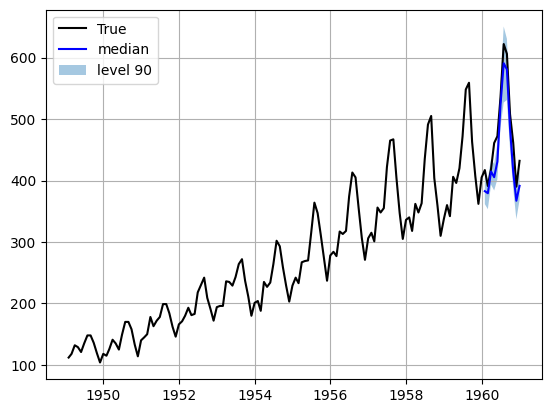

In [3]:
Y_hat_df = forecasts.reset_index(drop=False).drop(columns=["unique_id", "ds"])
plot_df = pd.concat([Y_test_df, Y_hat_df], axis=1)
plot_df = pd.concat([Y_train_df, plot_df])

if model.loss.is_distribution_output:
    plot_df = plot_df[plot_df.unique_id == "Airline1"].drop("unique_id", axis=1)
    plt.plot(plot_df["ds"], plot_df["y"], c="black", label="True")
    plt.plot(plot_df["ds"], plot_df["PatchTST-median"], c="blue", label="median")
    plt.fill_between(
        x=plot_df["ds"][-12:],
        y1=plot_df["PatchTST-lo-90"][-12:].values,
        y2=plot_df["PatchTST-hi-90"][-12:].values,
        alpha=0.4,
        label="level 90",
    )
    plt.grid()
    plt.legend()
    plt.plot()
else:
    plot_df = plot_df[plot_df.unique_id == "Airline1"].drop("unique_id", axis=1)
    plt.plot(plot_df["ds"], plot_df["y"], c="black", label="True")
    plt.plot(plot_df["ds"], plot_df["PatchTST"], c="blue", label="Forecast")
    plt.legend()
    plt.grid()

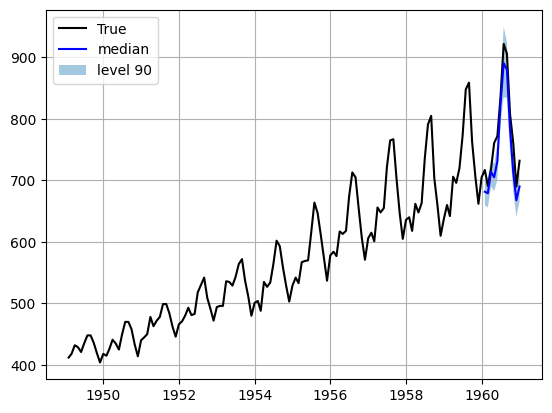

In [4]:
Y_hat_df = forecasts.reset_index(drop=False).drop(columns=["unique_id", "ds"])
plot_df = pd.concat([Y_test_df, Y_hat_df], axis=1)
plot_df = pd.concat([Y_train_df, plot_df])

if model.loss.is_distribution_output:
    plot_df = plot_df[plot_df.unique_id == "Airline2"].drop("unique_id", axis=1)
    plt.plot(plot_df["ds"], plot_df["y"], c="black", label="True")
    plt.plot(plot_df["ds"], plot_df["PatchTST-median"], c="blue", label="median")
    plt.fill_between(
        x=plot_df["ds"][-12:],
        y1=plot_df["PatchTST-lo-90"][-12:].values,
        y2=plot_df["PatchTST-hi-90"][-12:].values,
        alpha=0.4,
        label="level 90",
    )
    plt.grid()
    plt.legend()
    plt.plot()
else:
    plot_df = plot_df[plot_df.unique_id == "Airline2"].drop("unique_id", axis=1)
    plt.plot(plot_df["ds"], plot_df["y"], c="black", label="True")
    plt.plot(plot_df["ds"], plot_df["PatchTST"], c="blue", label="Forecast")
    plt.legend()
    plt.grid()